Importing the Dependencies

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Data Collection & Pre-Processing

In [19]:
# loading the data from csv file to a pandas Dataframe
raw_mail_data = pd.read_csv("/content/spam_ham_dataset.csv.zip")

In [20]:
raw_mail_data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [21]:
# replace the null values with a null string
mail_data = raw_mail_data.where((pd.notnull(raw_mail_data)),'')

In [22]:
# checking the number of rows and columns in the dataframe
mail_data.shape

(5171, 4)

Label Encoding

In [23]:
# label spam mail as 0;  ham mail as 1;

mail_data.loc[mail_data['label'] == 'spam', 'label',] = 0
mail_data.loc[mail_data['label'] == 'ham', 'label',] = 1

spam  -  0

ham  -  1

In [24]:
# separating the data as texts and label

X = mail_data['text']

Y = mail_data['label']

Splitting the data into training data & test data

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=3, stratify=Y)

Feature Extraction

In [26]:
# Convert email text into TF-IDF feature vectors

feature_extraction = TfidfVectorizer(min_df = 1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

# convert Y_train and Y_test values as integers

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

Training the Model

Logistic Regression

In [27]:
model = LogisticRegression(class_weight='balanced')

In [28]:
# training the Logistic Regression model with balanced class weights
model.fit(X_train_features, Y_train)

LogisticRegression(class_weight='balanced')

Evaluating the trained model

In [29]:
# prediction on training data

prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)

In [30]:
print('Accuracy on training data : ', accuracy_on_training_data)

Accuracy on training data :  0.9779980657640233


In [31]:
# prediction on test data

prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)


In [32]:
from sklearn.metrics import confusion_matrix
print('Accuracy on test data : ', accuracy_on_test_data)
print(
    confusion_matrix(
        Y_test,
       prediction_on_test_data
    ))

Accuracy on test data :  0.9710144927536232
[[300   0]
 [ 30 705]]




Building a Predictive System




In [33]:
input_mail = ["""Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes ."""]

# convert text to feature vectors
input_data_features = feature_extraction.transform(input_mail)

# making prediction

prediction = model.predict(input_data_features)
print(prediction)


if (prediction[0]==1):
  print('Ham mail')

else:
  print('Spam mail')

[1]
Ham mail


NAIVE BAYES MODEL

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [35]:
#CREATE MODEL
nb_model = MultinomialNB()

In [36]:
# Train model
nb_model.fit(X_train_features, Y_train)


MultinomialNB()

In [37]:
# Predict on test data
prediction = nb_model.predict(X_test_features)

In [38]:
# Find accuracy
accuracy = accuracy_score(Y_test, prediction)

print("Naive Bayes Accuracy:", accuracy)

Naive Bayes Accuracy: 0.9024154589371981


In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, prediction)

print(cm)

[[201  99]
 [  2 733]]


DECISION TREE ALGORITHM

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [41]:
# Create model
dt_model = DecisionTreeClassifier(max_depth=10,random_state=42)

In [42]:
# Train model
dt_model.fit(X_train_features, Y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [43]:
# Predict using test data
dt_prediction = dt_model.predict(X_test_features)

In [44]:
# Calculate accuracy
dt_accuracy = accuracy_score(Y_test, dt_prediction)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9043478260869565


In [45]:
train_prediction = dt_model.predict(X_train_features)

train_accuracy = accuracy_score(Y_train, train_prediction)

print("Training Accuracy:", train_accuracy)

print("Testing Accuracy:", dt_accuracy)

Training Accuracy: 0.9294003868471954
Testing Accuracy: 0.9043478260869565


RANDOM FOREST ALGORITHM

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
# Create model
rf_model = RandomForestClassifier(random_state=42)

In [48]:
# Train model
rf_model.fit(X_train_features, Y_train)

RandomForestClassifier(random_state=42)

In [49]:
# Prediction
rf_prediction = rf_model.predict(X_test_features)

In [50]:
# Accuracy
rf_accuracy = accuracy_score(Y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9816425120772947






COMPARISON GRAPH WITH LOGISTIC REGRESSION MODEL




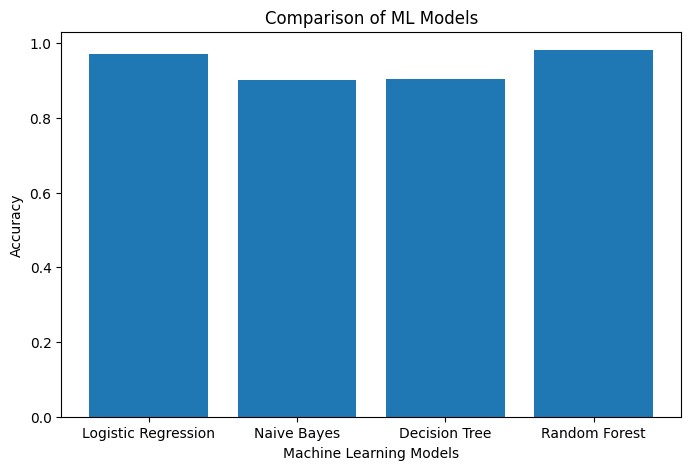

In [51]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Naive Bayes',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_on_test_data,
    accuracy,
    dt_accuracy,
    rf_accuracy
]


plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.title("Comparison of ML Models")

plt.show()